In [1]:
import pandas as pd  # For data tables
import numpy as np   # For math
import matplotlib.pyplot as plt # For charts
import seaborn as sns # For advanced charts

In [3]:
# Load the dataset
df = pd.read_csv('StudentPerformance.csv')

# See the first 5 rows to confirm it's loaded correctly
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
# 1. Generate descriptive statistics (Mean, Median, Max, etc.)
print(df.describe())

# 2. Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000000  
max             

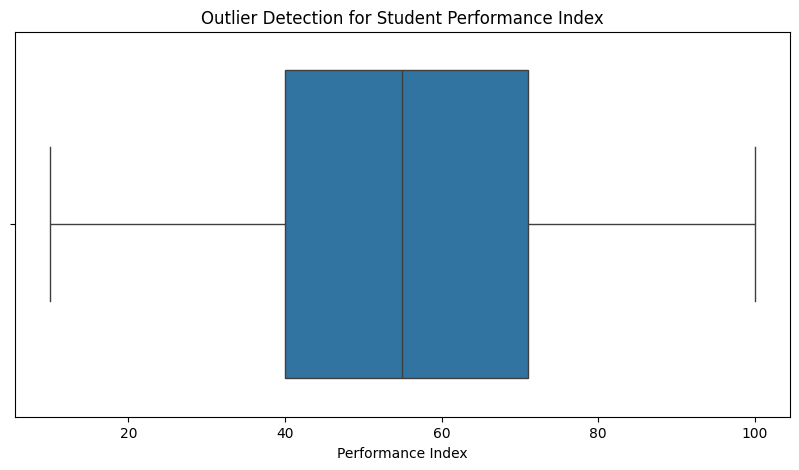

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Performance Index'])
plt.title('Outlier Detection for Student Performance Index')
plt.show()

In [7]:
target_col = 'Performance Index'

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['is_outlier'] = (df[target_col] < lower_bound) | (df[target_col] > upper_bound)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of outliers detected: {df['is_outlier'].sum()}")

Lower Bound: -6.5
Upper Bound: 117.5
Number of outliers detected: 0


In [8]:
df_cleaned = df[df['is_outlier'] == False]

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")

Original dataset size: 10000
Cleaned dataset size: 10000


In [9]:
df_cleaned.to_csv('cleaned_dataset.csv', index=False)
from google.colab import files
files.download('cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>